## ML Classical Baselines

In [1]:
import pandas as pd
from IPython.display import display

from utils.config import (
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
)
from utils.ML.ml_pipeline import (
    best_confusion_predictions,
    get_cache_path,
    get_results_path,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_or_build_none_reference_features,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    print_normalization_discriminability,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_block_vs_lovo_floor_plan,
    plot_block_vs_lovo_metrics,
    plot_csi_magnitude_stages,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_lovo_cdf_triptych,
    plot_lovo_volunteer_variability,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [2]:
CALIBRATION_MODE = "rssi"   # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline"
    ,  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"  # per_session | per_user | global (empty_baseline only)
SHOW_MAGNITUDE_PLOT = False

MAGNITUDE_PLOT_OPTIONS = {
    "position": "D-8",
    "user": "03",
    "trial": "01",
    "anchor_pair": 7,
    "packet_count": 60,
    "packet_selection": "middle",
    "normalized_limit_percentile": 99.0,
    "surface_elevation": 28,
    "surface_azimuth": -135,
    "save": False,
    "output_directory": "outputs/magnitude_plots",
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

MODELS_TO_RUN = ("RF", "KNN", "SVM")
SPLIT_MODES = ("block", "lovo")  # cross_session, lovo, random, block
RUN_CLASSIFICATION = False
RUN_GRID_SEARCH = False
REQUIRE_TUNED_PARAMS = True  # True -> require an exact matching grid-search run
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
N_JOBS = 8

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
if preproc_opts.get("normalization") == "empty_baseline":
    preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
tables_dir = results_dir / "tables"
plots_dir = results_dir / "plots"
for directory in (tables_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results


## Raw Data

In [3]:
loaded_csi_data = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    return_magnitude_stages=SHOW_MAGNITUDE_PLOT,
)
magnitude_data, csv_diagnostics = loaded_csi_data[:2]
magnitude_plot_stages = loaded_csi_data[2] if SHOW_MAGNITUDE_PLOT else None

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19


In [4]:
if SHOW_MAGNITUDE_PLOT:
    plot_csi_magnitude_stages(magnitude_plot_stages, **MAGNITUDE_PLOT_OPTIONS)

#### Feature Dataframes

In [5]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)

none_reference_dataframes = (
    feature_dataframes
    if preproc_opts.get("normalization") == "none"
    else load_or_build_none_reference_features(
        magnitude_data,
        active_preproc_opts=preproc_opts,
        feat_opts=feat_opts,
    )
)
fisher_diagnostics = print_normalization_discriminability(
    feature_dataframes,
    normalization=preproc_opts.get("normalization", "none"),
    reference_feature_dataframes=none_reference_dataframes,
    bands_to_run=BANDS_TO_RUN,
)
display(fisher_diagnostics)
del magnitude_data


[features] resolved cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/2_4ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/5ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/fusion.parquet
2.4 GHz: 13588 windows, 2708 columns
5 GHz: 14478 windows, 3368 columns
Fusion: 13568 windows, 6068 columns
[normalization diagnostic] none reference cache: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-none/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc

,dataset,normalization,median_fisher_ratio,none_median_fisher_ratio
0,2.4 GHz,empty_baseline,0.069480,0.028427
1,5 GHz,empty_baseline,0.067411,0.030535
2,Fusion,empty_baseline,0.069267,0.029641


#### Model Parameters

In [6]:
params_lookup = {}
if RUN_GRID_SEARCH:
    print("Parameter lookup deferred until the requested grid search completes.")
else:
    params_lookup = load_params_lookup(
        results_dir,
        models_to_run=MODELS_TO_RUN,
        bands_to_run=BANDS_TO_RUN,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        require_tuned_params=REQUIRE_TUNED_PARAMS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
    )
    for key, value in params_lookup.items():
        print(f"{key}: {value}")

[tuned params] exact runs.csv match: RF / 2.4 GHz / run_id=ml__rf__2_4ghz__grid_search__ebl-session__s42__d8d534
[tuned params] exact runs.csv match: RF / 5 GHz / run_id=ml__rf__5ghz__grid_search__ebl-session__s42__0249b6
[tuned params] exact runs.csv match: RF / Fusion / run_id=ml__rf__fusion__grid_search__ebl-session__s42__666a25
[tuned params] exact runs.csv match: KNN / 2.4 GHz / run_id=ml__knn__2_4ghz__grid_search__ebl-session__s42__d47768
[tuned params] exact runs.csv match: KNN / 5 GHz / run_id=ml__knn__5ghz__grid_search__ebl-session__s42__80bca5
[tuned params] exact runs.csv match: KNN / Fusion / run_id=ml__knn__fusion__grid_search__ebl-session__s42__5b6367
[tuned params] exact runs.csv match: SVM / 2.4 GHz / run_id=ml__svm__2_4ghz__grid_search__ebl-session__s42__3be980
[tuned params] exact runs.csv match: SVM / 5 GHz / run_id=ml__svm__5ghz__grid_search__ebl-session__s42__0f2dc1
[tuned params] exact runs.csv match: SVM / Fusion / run_id=ml__svm__fusion__grid_search__ebl-session

##### Optional Grid Search

In [7]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [8]:
if RUN_CLASSIFICATION:
    global_summary, global_predictions_by_key = run_global_baselines(
        feature_dataframes,
        params_lookup=params_lookup,
        models_to_run=MODELS_TO_RUN,
        bands_to_run=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        n_jobs=N_JOBS,
        results_dir=results_dir,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        force_retrain=FORCE_RETRAIN,
        save_predictions=SAVE_PREDICTIONS,
        svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
    display(global_summary)
    run_registry = pd.read_csv(results_dir / "runs.csv")
    active_run_ids = run_registry.loc[
        run_registry["model"].isin([model.lower() for model in MODELS_TO_RUN])
        & run_registry["split"].isin(SPLIT_MODES),
        "run_id",
    ]
    if active_run_ids.empty:
        raise RuntimeError("No active run_id is available for plot storage.")
    plots_dir = results_dir / "plots" / active_run_ids.iloc[0]
    plots_dir.mkdir(parents=True, exist_ok=True)
else:
    print("Classification skipped because RUN_CLASSIFICATION is False.")


Classification skipped because RUN_CLASSIFICATION is False.


#### Analysis Tables

Tables are grouped by evaluation split: Temporal Block, Leave-One-Volunteer-Out (LOVO), and Block versus LOVO (shown only when both splits are available).

In [9]:
# Set to False to save every figure below without rendering it inline (e.g. non-interactive/batch runs).
DISPLAY_PLOTS = True

all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=results_dir / "runs.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

available_splits = set(master_table["split"].astype(str)) if not master_table.empty else set()
has_block = "block" in SPLIT_MODES and "block" in available_splits

# load_lovo_summary_tables() reads every LOVO row in runs.csv without a model filter, so
# it can also return DL (CNN) runs saved by the other notebook; keep this classical-ML-only.
ml_model_set = {model.upper() for model in MODELS_TO_RUN}
lovo_per_fold = pd.DataFrame()
lovo_summary = pd.DataFrame()
lovo_table = pd.DataFrame()
has_lovo = False
if "lovo" in SPLIT_MODES:
    try:
        raw_lovo_per_fold, raw_lovo_summary = load_lovo_summary_tables(results_dir)
        lovo_summary = raw_lovo_summary.loc[
            raw_lovo_summary["model"].astype(str).str.upper().isin(ml_model_set)
        ].reset_index(drop=True)
        lovo_per_fold = raw_lovo_per_fold.loc[
            raw_lovo_per_fold["model"].astype(str).str.upper().isin(ml_model_set)
        ].reset_index(drop=True)
        if lovo_summary.empty:
            raise ValueError("No classical-ML LOVO runs remain after excluding DL results.")
        lovo_table = lovo_aggregated_analysis_table(lovo_summary)
        save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)
        has_lovo = True
    except (FileNotFoundError, ValueError) as error:
        print(f"LOVO analysis skipped: {error}")

print(f"Temporal Block available: {has_block} | LOVO available: {has_lovo}")

[tables] per-room predictions remain analysis-only and are not a runs.csv view.
Temporal Block available: True | LOVO available: True


##### Temporal Block

In [10]:
if has_block:
    display(master_table.loc[master_table["split"] == "block"].reset_index(drop=True))
    display(per_room_table.loc[per_room_table["split"] == "block"].reset_index(drop=True))
else:
    print("Temporal Block tables skipped: the block split is not selected or unavailable.")

,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,...,rmse_distance_error_std,p90_distance_error_mean,p90_distance_error_std,position_accuracy_pooled,majority_position_accuracy,majority_room_accuracy,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,KNN,2.4 GHz,block,0.62069,0.626367,0.932471,1.210821,0.0,2.517182,4.123106,...,NaN,NaN,NaN,NaN,0.025144,0.651580,0.201338,0.696065,0.923813,KNeighborsClassifier
1,RF,2.4 GHz,block,0.798132,0.799427,0.969109,0.54515,0.0,1.648754,2.0,...,NaN,NaN,NaN,NaN,0.025144,0.651580,6.827108,0.194984,7.045492,RandomForestClassifier
2,SVM,2.4 GHz,block,0.719109,0.721358,0.948994,0.860698,0.0,2.102783,3.162278,...,NaN,NaN,NaN,NaN,0.025144,0.651580,14.268487,14.336501,28.628788,SVC
3,KNN,5 GHz,block,0.430825,0.432867,0.899879,1.622549,1.0,2.668019,4.123106,...,NaN,NaN,NaN,NaN,0.021845,0.660801,0.312899,1.075773,1.424527,KNeighborsClassifier
4,RF,5 GHz,block,0.803398,0.800625,0.98665,0.402393,0.0,1.105481,1.414214,...,NaN,NaN,NaN,NaN,0.021845,0.660801,29.345752,0.202651,29.580212,RandomForestClassifier
5,SVM,5 GHz,block,0.575243,0.573387,0.964806,1.001739,0.0,1.842724,3.162278,...,NaN,NaN,NaN,NaN,0.021845,0.660801,23.183033,26.197445,49.412826,SVC
6,KNN,Fusion,block,0.670029,0.671996,0.950288,0.885211,0.0,1.950947,3.048683,...,NaN,NaN,NaN,NaN,0.024496,0.652738,0.461158,1.543041,2.029885,KNeighborsClassifier
7,RF,Fusion,block,0.895533,0.89604,0.994236,0.213698,0.0,0.828178,1.0,...,NaN,NaN,NaN,NaN,0.024496,0.652738,5.906932,0.219395,6.151509,RandomForestClassifier
8,SVM,Fusion,block,0.752161,0.749324,0.979827,0.589499,0.0,1.488186,2.236068,...,NaN,NaN,NaN,NaN,0.024496,0.652738,88.431798,74.360800,162.817518,SVC


,model,dataset,split,true_room,samples,position_accuracy
0,KNN,2.4 GHz,block,1,907,0.604190
1,KNN,2.4 GHz,block,2,268,0.660448
2,KNN,2.4 GHz,block,3,217,0.640553
3,RF,2.4 GHz,block,1,907,0.796031
4,RF,2.4 GHz,block,2,268,0.794776
5,RF,2.4 GHz,block,3,217,0.811060
6,SVM,2.4 GHz,block,1,907,0.710033
7,SVM,2.4 GHz,block,2,268,0.738806
8,SVM,2.4 GHz,block,3,217,0.732719
9,KNN,5 GHz,block,1,1089,0.381084


##### Leave-One-Volunteer-Out (LOVO)

In [11]:
if has_lovo:
    print("Fold mean +/- fold standard deviation, per model x band:")
    display(lovo_table)

    print("Per-fold position accuracy (RF):")
    display(
        lovo_per_fold.loc[lovo_per_fold["model"].str.upper() == "RF"].reset_index(drop=True)
    )

    pooled_columns = [
        column
        for column in ("model", "dataset", "position_accuracy_pooled")
        if column in lovo_summary.columns
    ]
    if pooled_columns:
        print("Pooled position accuracy (all held-out predictions combined, not fold-averaged):")
        display(
            lovo_summary[pooled_columns].sort_values(["dataset", "model"]).reset_index(drop=True)
        )

    majority_columns = [
        column
        for column in (
            "model",
            "dataset",
            "majority_position_accuracy_mean_std",
            "majority_room_accuracy_mean_std",
        )
        if column in lovo_table.columns
    ]
    if majority_columns:
        print("Majority-class baseline (fold mean +/- fold standard deviation):")
        display(lovo_table[majority_columns])
else:
    print("LOVO tables skipped: the LOVO split is not selected or unavailable.")

Fold mean +/- fold standard deviation, per model x band:


,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,KNN,2.4 GHz,0.0898 +/- 0.0309,0.0855 +/- 0.0327,0.4889 +/- 0.0770,5.1466 +/- 0.3095,4.1327 +/- 0.3244,6.4296 +/- 0.2522,11.2002 +/- 0.2558,0.0207 +/- 0.0011,0.6514 +/- 0.0134
1,RF,2.4 GHz,0.1737 +/- 0.0557,0.1387 +/- 0.0567,0.5844 +/- 0.0740,3.9853 +/- 0.2617,3.1550 +/- 0.6746,5.2729 +/- 0.3020,9.3593 +/- 1.1335,0.0207 +/- 0.0011,0.6514 +/- 0.0134
2,SVM,2.4 GHz,0.1614 +/- 0.0686,0.1442 +/- 0.0691,0.6382 +/- 0.0970,4.0503 +/- 0.3413,3.1944 +/- 0.5960,5.3524 +/- 0.5592,9.4565 +/- 1.4454,0.0207 +/- 0.0011,0.6514 +/- 0.0134
3,KNN,5 GHz,0.0728 +/- 0.0180,0.0615 +/- 0.0174,0.3913 +/- 0.1187,5.2942 +/- 0.7426,4.7643 +/- 0.8726,6.3329 +/- 0.8258,10.5364 +/- 1.3343,0.0196 +/- 0.0003,0.6557 +/- 0.0037
4,RF,5 GHz,0.1240 +/- 0.0587,0.0971 +/- 0.0431,0.6659 +/- 0.1410,3.7053 +/- 0.5488,3.5223 +/- 0.5589,4.4725 +/- 0.5609,7.3312 +/- 1.0406,0.0196 +/- 0.0003,0.6557 +/- 0.0037
5,SVM,5 GHz,0.1191 +/- 0.0347,0.0969 +/- 0.0387,0.6516 +/- 0.1428,3.9461 +/- 0.7903,3.3753 +/- 0.8535,5.0578 +/- 0.9626,8.7587 +/- 1.7723,0.0196 +/- 0.0003,0.6557 +/- 0.0037
6,KNN,Fusion,0.1001 +/- 0.0397,0.0911 +/- 0.0436,0.4235 +/- 0.0779,5.0544 +/- 0.4845,4.4490 +/- 0.4972,6.2286 +/- 0.5174,10.4467 +/- 0.8595,0.0201 +/- 0.0012,0.6521 +/- 0.0134
7,RF,Fusion,0.1896 +/- 0.0850,0.1552 +/- 0.0718,0.6868 +/- 0.1666,3.3521 +/- 0.7847,2.8777 +/- 1.2095,4.2629 +/- 0.7740,7.0559 +/- 1.3111,0.0201 +/- 0.0012,0.6521 +/- 0.0134
8,SVM,Fusion,0.1602 +/- 0.0722,0.1366 +/- 0.0733,0.6982 +/- 0.0776,3.6535 +/- 0.3441,2.8733 +/- 0.5411,4.7719 +/- 0.5568,8.3141 +/- 1.5653,0.0201 +/- 0.0012,0.6521 +/- 0.0134


Per-fold position accuracy (RF):


,run_id,fold,held_out_user,validation_user,n_train_windows,n_test_windows,trials_used,position_accuracy,macro_f1,room_accuracy,...,wall_seconds,parameter_count,best_val_accuracy,best_epoch,mean_seconds_per_epoch,samples,stopped_epoch,patience_triggered,model,dataset
0,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,1,01,NaN,7336,1570,1,0.161783,0.124330,0.531210,...,NaN,NaN,NaN,NaN,NaN,1570.0,NaN,NaN,RF,2.4 GHz
1,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,2,02,NaN,7492,1414,1,0.114569,0.083670,0.515559,...,NaN,NaN,NaN,NaN,NaN,1414.0,NaN,NaN,RF,2.4 GHz
2,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,3,03,NaN,7319,1587,1,0.137366,0.099238,0.514178,...,NaN,NaN,NaN,NaN,NaN,1587.0,NaN,NaN,RF,2.4 GHz
3,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,4,04,NaN,7346,1560,1,0.217308,0.171542,0.689744,...,NaN,NaN,NaN,NaN,NaN,1560.0,NaN,NaN,RF,2.4 GHz
4,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,5,05,NaN,7420,1486,1,0.263122,0.237218,0.625168,...,NaN,NaN,NaN,NaN,NaN,1486.0,NaN,NaN,RF,2.4 GHz
5,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,6,06,NaN,7617,1289,1,0.148177,0.116337,0.630721,...,NaN,NaN,NaN,NaN,NaN,1289.0,NaN,NaN,RF,2.4 GHz
6,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,1,01,NaN,8067,1628,1,0.095209,0.075580,0.671376,...,NaN,NaN,NaN,NaN,NaN,1628.0,NaN,NaN,RF,5 GHz
7,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,2,02,NaN,8097,1598,1,0.056946,0.050668,0.591364,...,NaN,NaN,NaN,NaN,NaN,1598.0,NaN,NaN,RF,5 GHz
8,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,3,03,NaN,8081,1614,1,0.089839,0.069183,0.432466,...,NaN,NaN,NaN,NaN,NaN,1614.0,NaN,NaN,RF,5 GHz
9,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,4,04,NaN,8060,1635,1,0.159633,0.127025,0.813456,...,NaN,NaN,NaN,NaN,NaN,1635.0,NaN,NaN,RF,5 GHz


Pooled position accuracy (all held-out predictions combined, not fold-averaged):


,model,dataset,position_accuracy_pooled
0,KNN,2.4 GHz,0.090389
1,RF,2.4 GHz,0.174601
2,SVM,2.4 GHz,0.163934
3,KNN,5 GHz,0.072924
4,RF,5 GHz,0.124188
5,SVM,5 GHz,0.119340
6,KNN,Fusion,0.100799
7,RF,Fusion,0.188998
8,SVM,Fusion,0.163460


Majority-class baseline (fold mean +/- fold standard deviation):


,model,dataset,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,KNN,2.4 GHz,0.0207 +/- 0.0011,0.6514 +/- 0.0134
1,RF,2.4 GHz,0.0207 +/- 0.0011,0.6514 +/- 0.0134
2,SVM,2.4 GHz,0.0207 +/- 0.0011,0.6514 +/- 0.0134
3,KNN,5 GHz,0.0196 +/- 0.0003,0.6557 +/- 0.0037
4,RF,5 GHz,0.0196 +/- 0.0003,0.6557 +/- 0.0037
5,SVM,5 GHz,0.0196 +/- 0.0003,0.6557 +/- 0.0037
6,KNN,Fusion,0.0201 +/- 0.0012,0.6521 +/- 0.0134
7,RF,Fusion,0.0201 +/- 0.0012,0.6521 +/- 0.0134
8,SVM,Fusion,0.0201 +/- 0.0012,0.6521 +/- 0.0134


##### Block versus LOVO

In [12]:
if has_block and has_lovo:
    comparison_rows = []
    for _, block_row in master_table.loc[master_table["split"] == "block"].iterrows():
        lovo_row = lovo_summary.loc[
            (lovo_summary["model"] == block_row["model"])
            & (lovo_summary["dataset"] == block_row["dataset"])
        ]
        if lovo_row.empty:
            continue
        lovo_row = lovo_row.iloc[0]
        comparison_rows.append(
            {
                "model": block_row["model"],
                "dataset": block_row["dataset"],
                "block_position_accuracy": block_row["position_accuracy"],
                "lovo_position_accuracy_mean": lovo_row["position_accuracy_mean"],
                "lovo_position_accuracy_std": lovo_row["position_accuracy_std"],
                "generalization_gap": (
                    block_row["position_accuracy"] - lovo_row["position_accuracy_mean"]
                ),
            }
        )
    block_vs_lovo_table = (
        pd.DataFrame(comparison_rows).sort_values(["dataset", "model"]).reset_index(drop=True)
    )
    display(block_vs_lovo_table)
else:
    print("Block vs LOVO comparison table skipped: both splits are required.")

,model,dataset,block_position_accuracy,lovo_position_accuracy_mean,lovo_position_accuracy_std,generalization_gap
0,KNN,2.4 GHz,0.620690,0.089778,0.030900,0.530911
1,RF,2.4 GHz,0.798132,0.173721,0.055692,0.624411
2,SVM,2.4 GHz,0.719109,0.161410,0.068592,0.557699
3,KNN,5 GHz,0.430825,0.072827,0.017969,0.357998
4,RF,5 GHz,0.803398,0.124050,0.058722,0.679348
5,SVM,5 GHz,0.575243,0.119117,0.034701,0.456126
6,KNN,Fusion,0.670029,0.100105,0.039675,0.569924
7,RF,Fusion,0.895533,0.189583,0.084964,0.705950
8,SVM,Fusion,0.752161,0.160186,0.072172,0.591975


#### Temporal Block Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_by_model_block_2-4-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


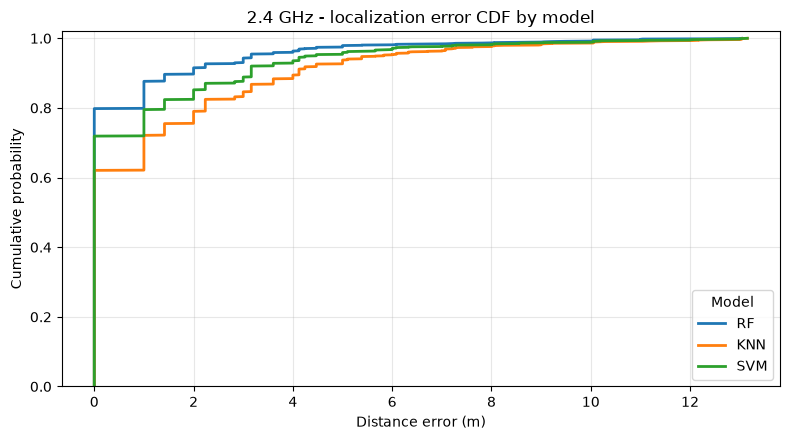

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_by_model_block_5-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


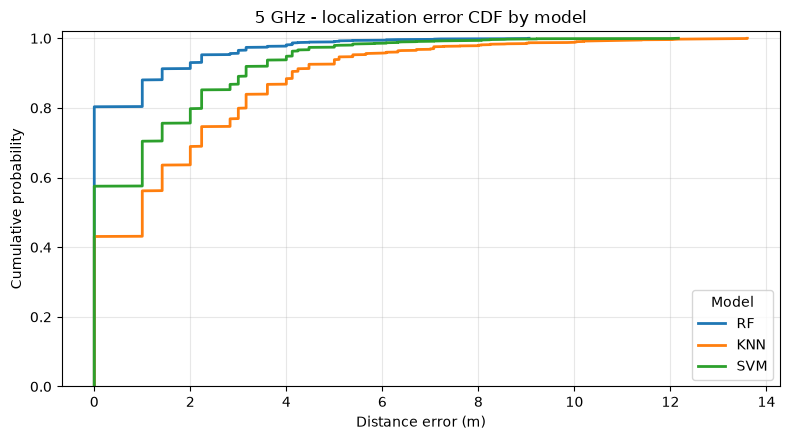

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_by_model_block_fusion.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


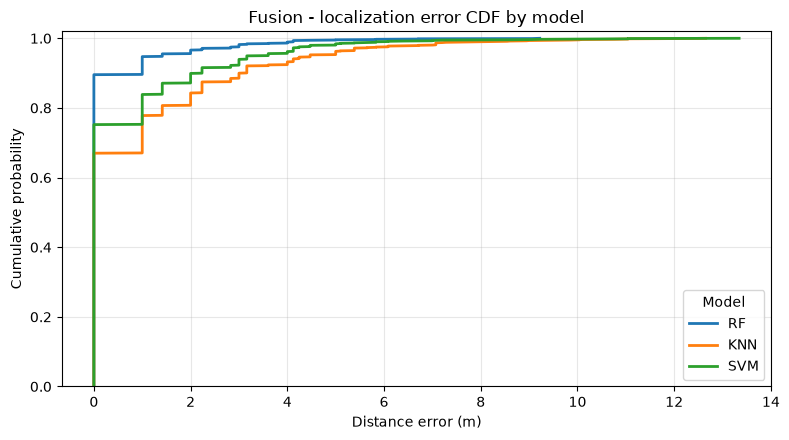

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_rf_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


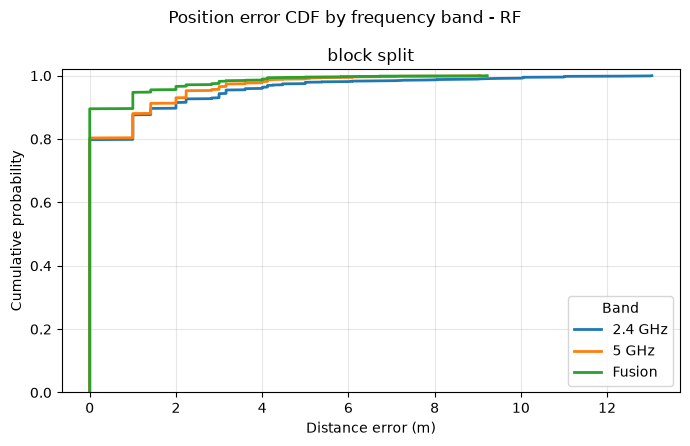

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_knn_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


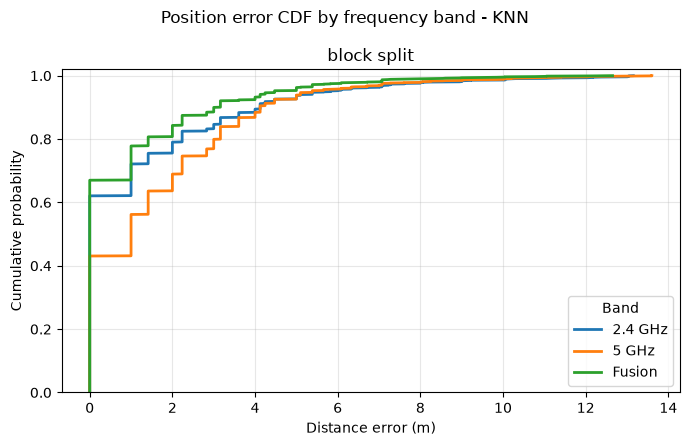

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_svm_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


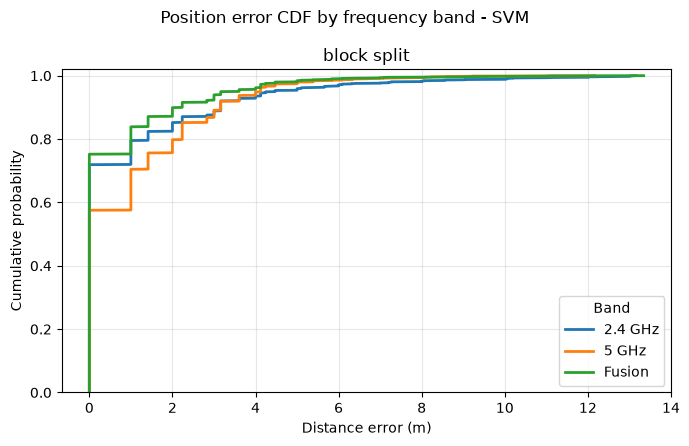

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/boxplot_block_model_band_distance_error.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


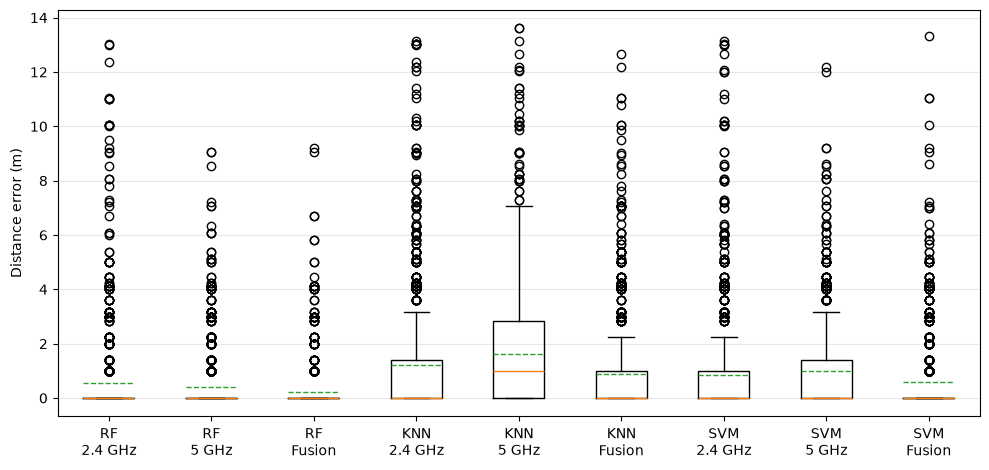

Temporal Block confusion/floor-plan model: RF on Fusion
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/floor_plan_block_fusion_rf.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


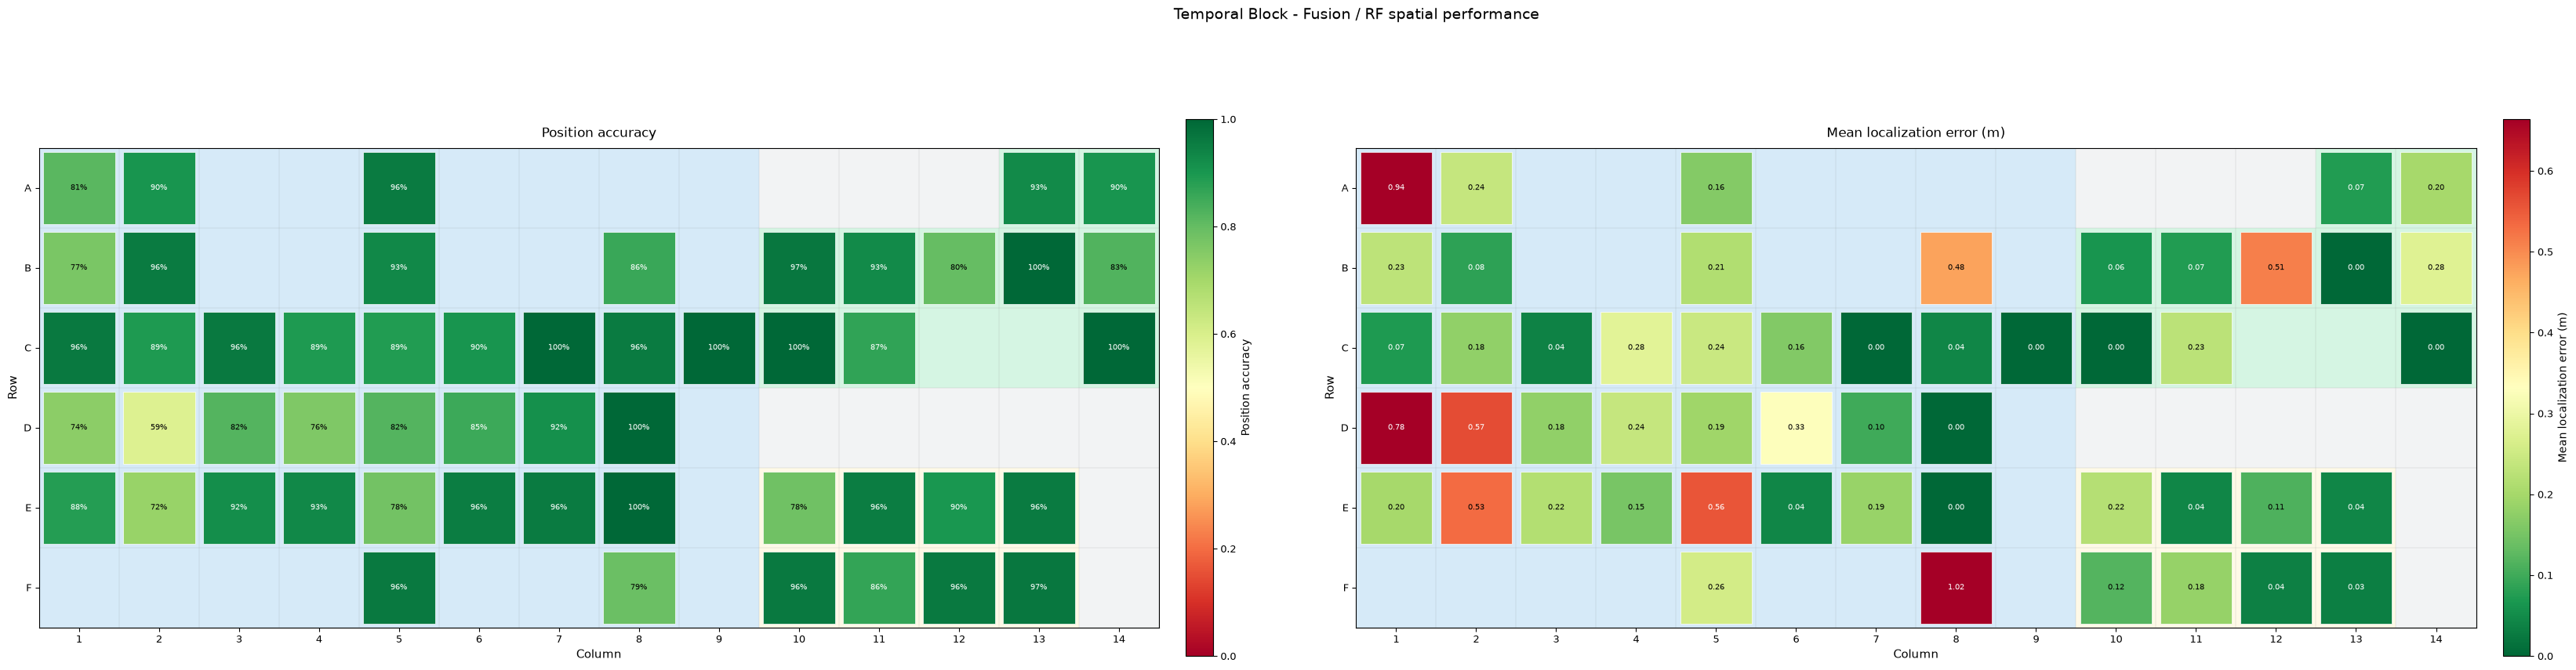

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/confusion_block_fusion_rf.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


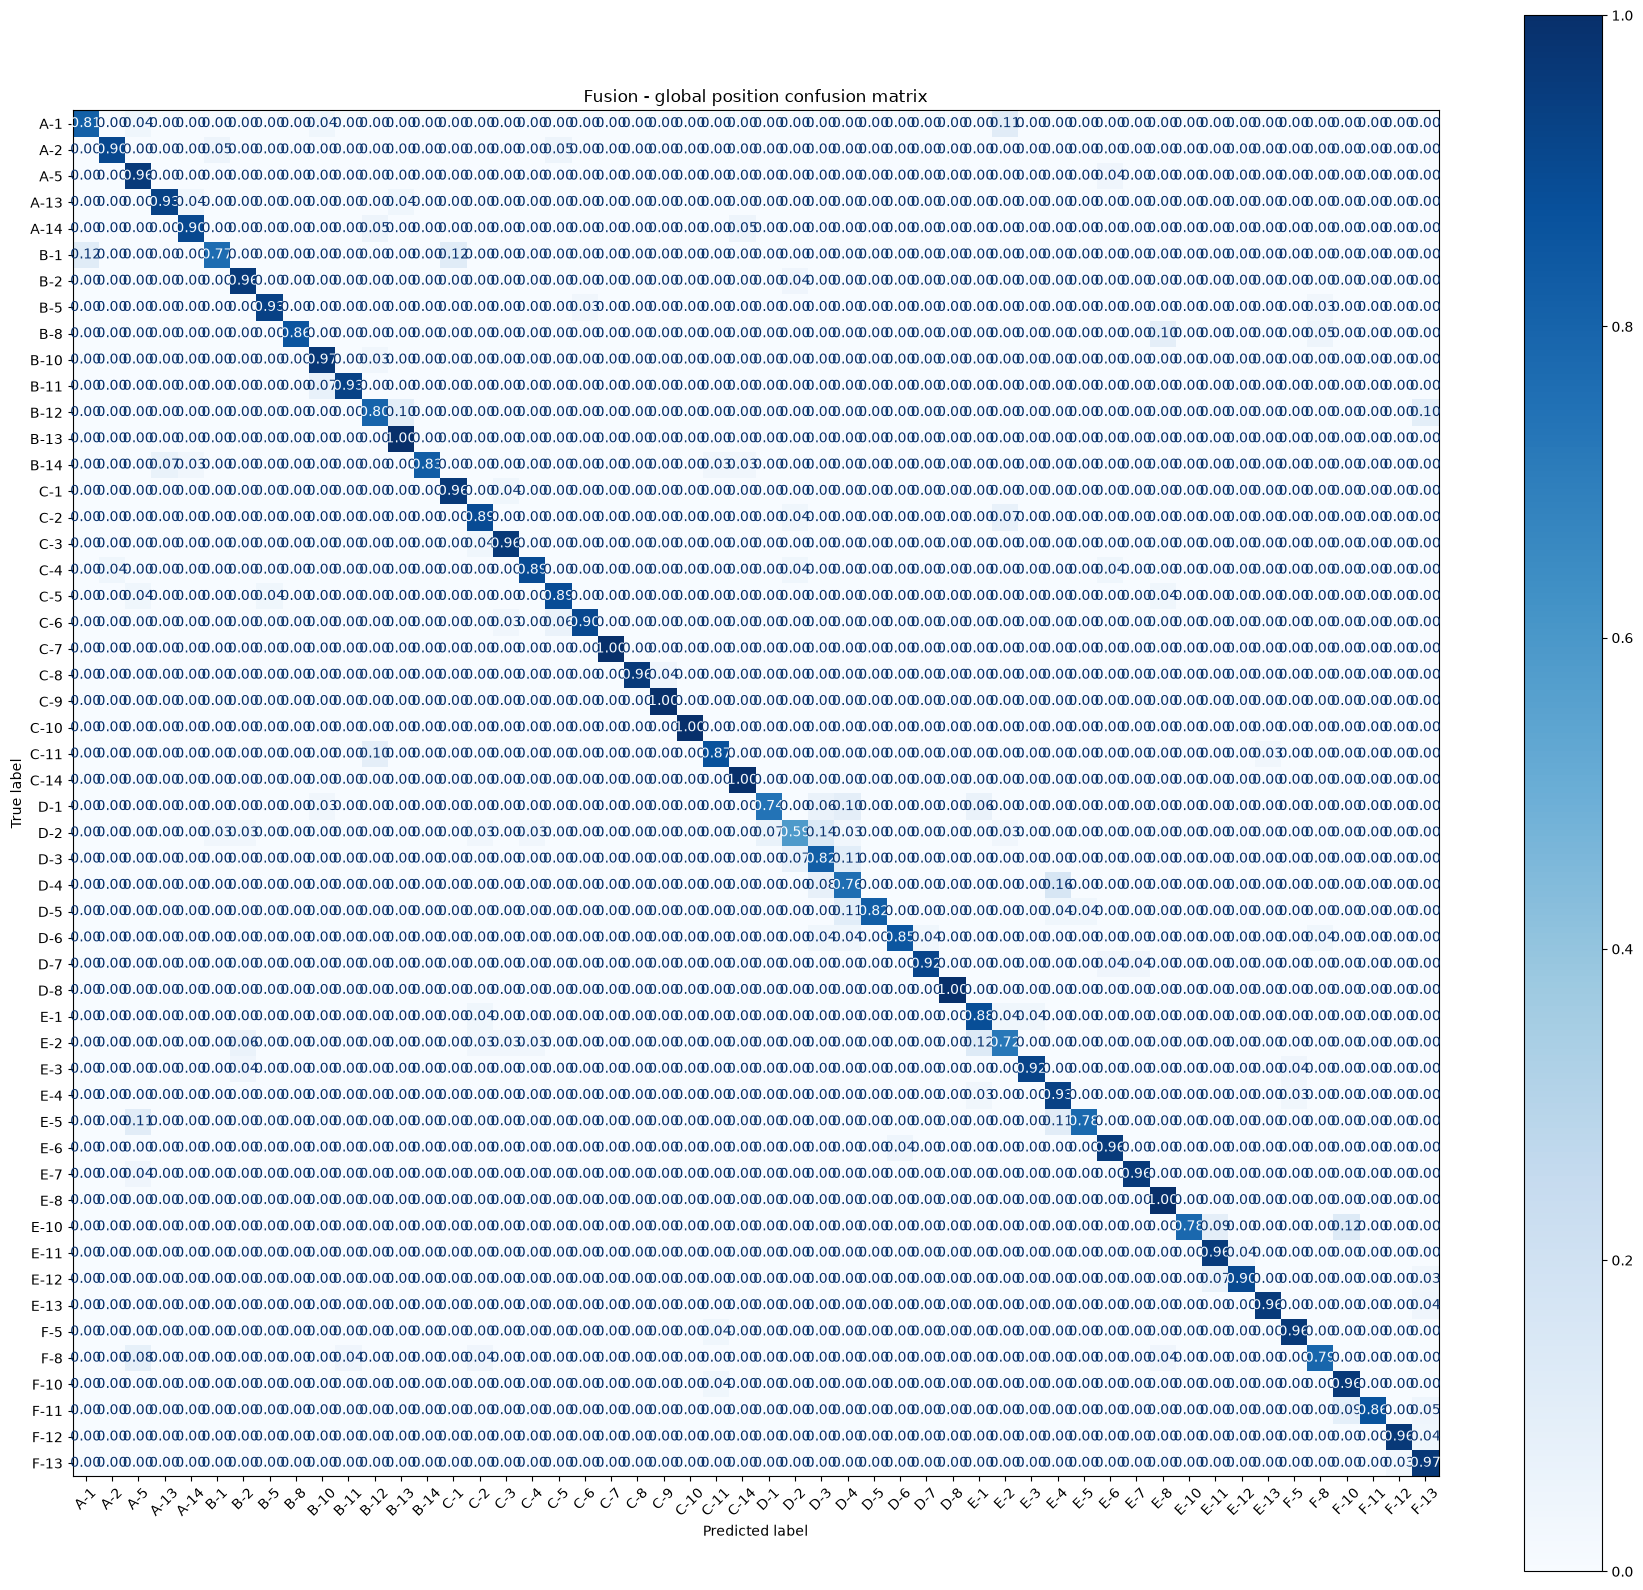

In [13]:
if has_block:
    block_predictions = all_global_predictions.loc[all_global_predictions["split_mode"] == "block"]

    if SHOW_CDF_BY_BAND:
        for band in BANDS_TO_RUN:
            plot_localization_error_cdf_by_model(
                block_predictions,
                dataset=band,
                save_path=plots_dir / f"cdf_by_model_block_{_slugify(band)}.png",
                show=DISPLAY_PLOTS,
            )

    if SHOW_CDF_BY_MODEL:
        for model in MODELS_TO_RUN:
            model_predictions = block_predictions.loc[block_predictions["model"] == model]
            plot_band_error_cdf(
                model_predictions,
                model_label=model,
                split_modes=("block",),
                band_order=BANDS_TO_RUN,
                save_path=plots_dir,
                show=DISPLAY_PLOTS,
            )

    if SHOW_BOXPLOT:
        plot_model_band_error_boxplot(
            block_predictions,
            models=MODELS_TO_RUN,
            bands=BANDS_TO_RUN,
            save_path=plots_dir / "boxplot_block_model_band_distance_error.png",
            show=DISPLAY_PLOTS,
        )

    block_confusion_model, block_confusion_predictions = best_confusion_predictions(
        all_global_predictions,
        master_table.loc[master_table["split"] == "block"],
        dataset=CONFUSION_DATASET,
        model=CONFUSION_MODEL,
        split="block",
    )
    print(f"Temporal Block confusion/floor-plan model: {block_confusion_model} on {CONFUSION_DATASET}")

    if SHOW_FLOOR_PLAN:
        plot_floor_plan_heatmap(
            block_confusion_predictions,
            title=f"Temporal Block - {CONFUSION_DATASET} / {block_confusion_model} spatial performance",
            save_path=(
                plots_dir
                / f"floor_plan_block_{_slugify(CONFUSION_DATASET)}_{_slugify(block_confusion_model)}.png"
            ),
            show=DISPLAY_PLOTS,
        )

    if SHOW_CONFUSION_MATRICES:
        plot_global_position_confusion_matrix(
            block_confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=(
                plots_dir
                / f"confusion_block_{_slugify(CONFUSION_DATASET)}_{_slugify(block_confusion_model)}.png"
            ),
            show=DISPLAY_PLOTS,
        )
        if SHOW_PER_ROOM_PLOTS:
            room_plot_dir = (
                plots_dir
                / f"confusion_by_room_block_{_slugify(CONFUSION_DATASET)}_{_slugify(block_confusion_model)}"
            )
            plot_position_confusion_by_true_room(
                block_confusion_predictions,
                dataset=CONFUSION_DATASET,
                normalize="true",
                save_path=room_plot_dir,
                show=DISPLAY_PLOTS,
            )
else:
    print("Temporal Block plots skipped: the block split is not selected or unavailable.")

#### LOVO Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_triptych_lovo_rf-knn-svm.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


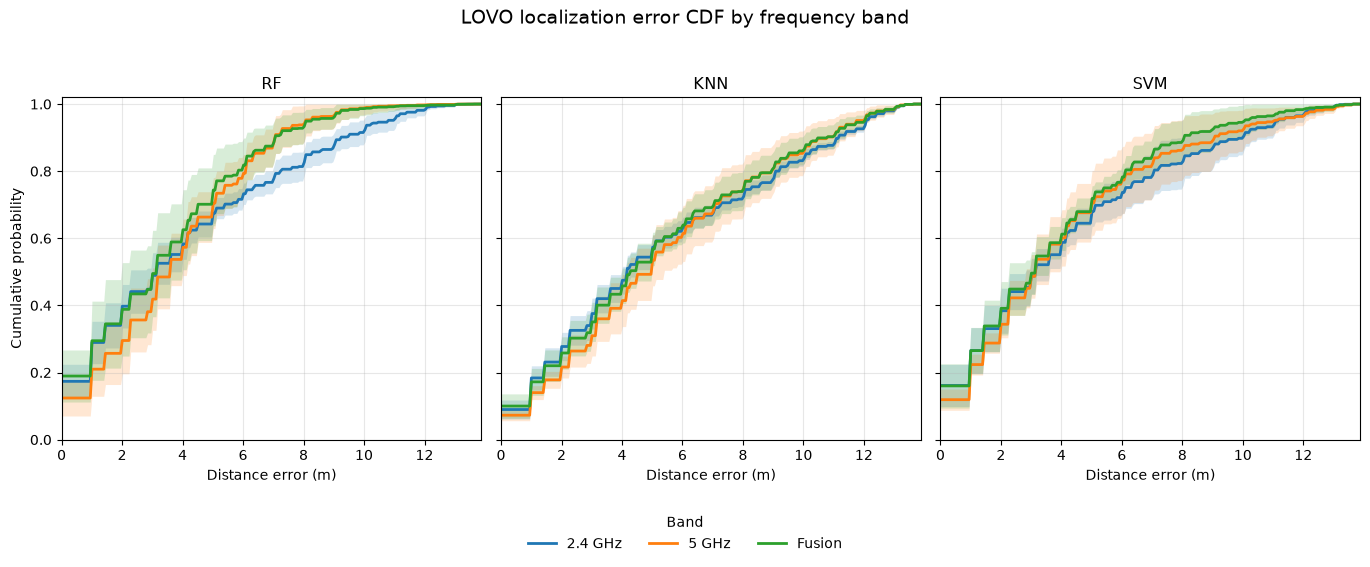

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/lovo_rf_variability_slope.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


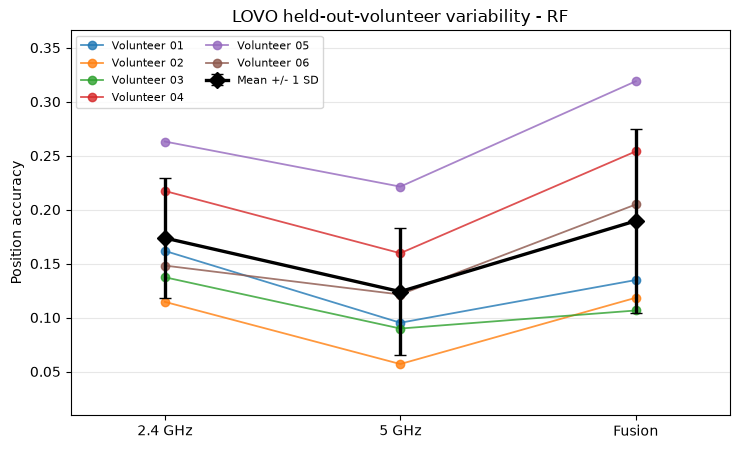

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/floor_plan_lovo_fusion_rf.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


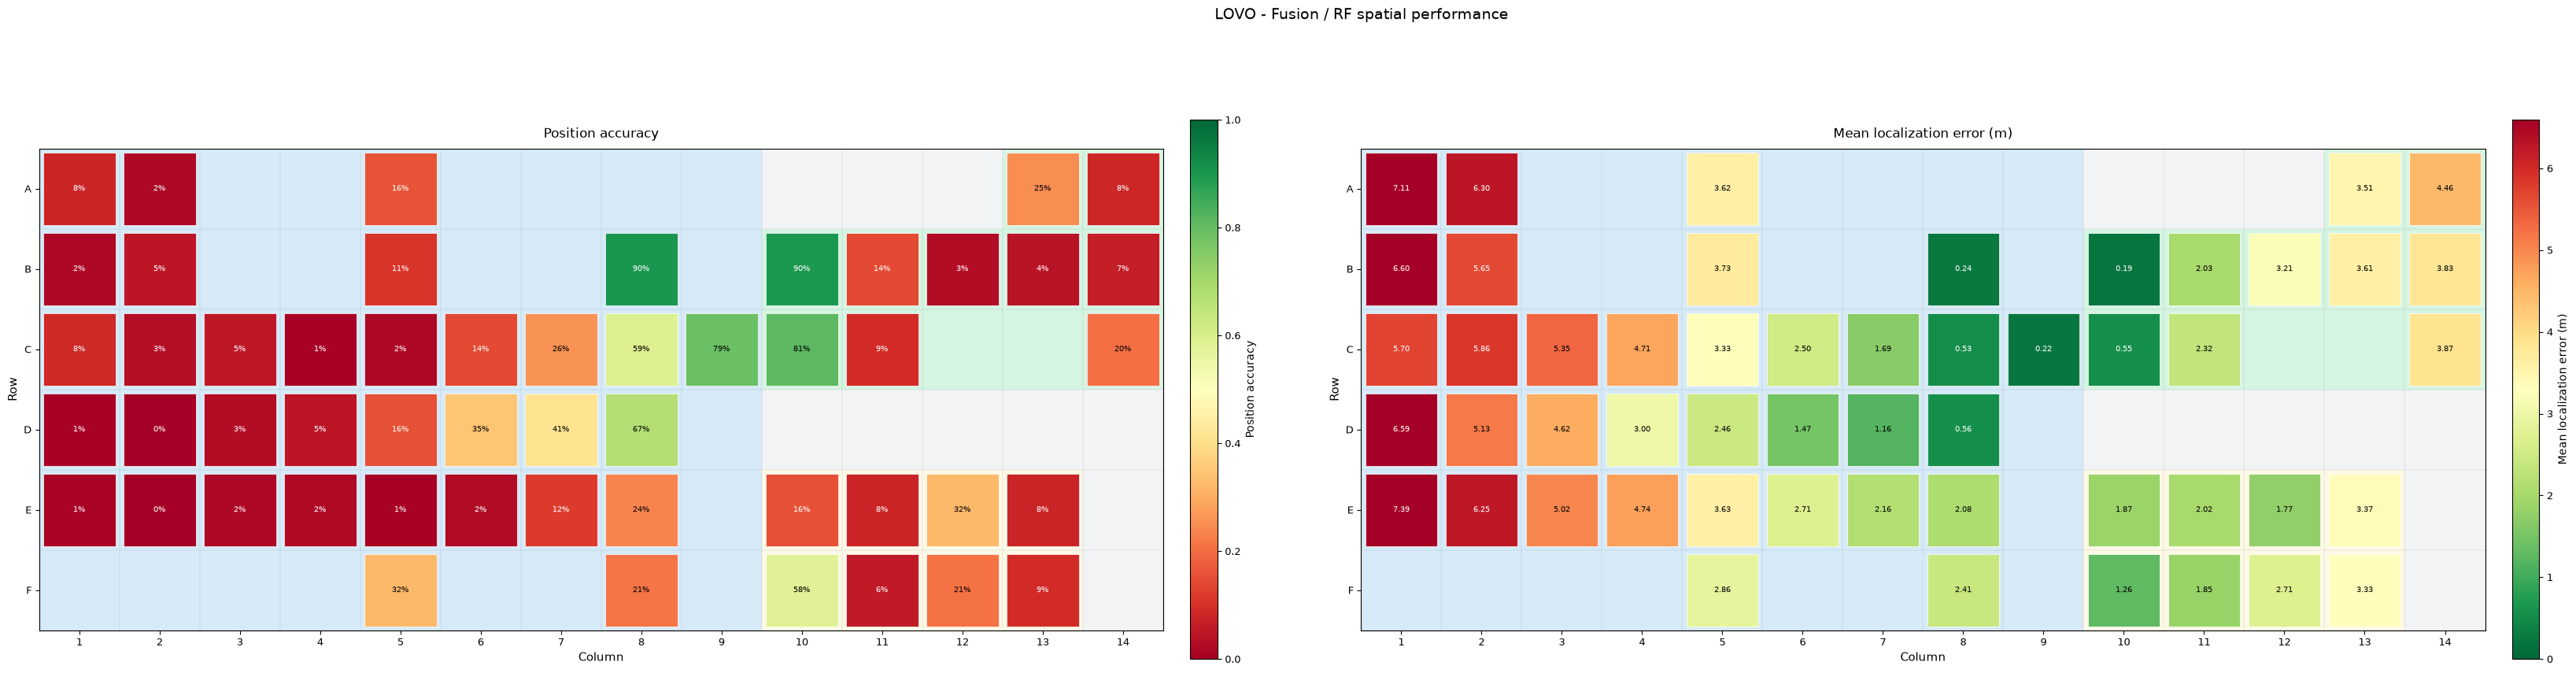

In [14]:
if has_lovo:
    lovo_predictions = all_global_predictions.loc[all_global_predictions["split_mode"] == "lovo"]
    lovo_model_slug = "-".join(_slugify(model) for model in MODELS_TO_RUN)

    plot_lovo_cdf_triptych(
        lovo_predictions,
        models=MODELS_TO_RUN,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / f"cdf_triptych_lovo_{lovo_model_slug}.png",
        show=DISPLAY_PLOTS,
    )

    plot_lovo_volunteer_variability(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"lovo_{_slugify('RF')}_variability_slope.png",
        show=DISPLAY_PLOTS,
    )

    lovo_fusion_rf_predictions = lovo_predictions.loc[
        (lovo_predictions["model"] == "RF") & (lovo_predictions["dataset"] == "Fusion")
    ]
    plot_floor_plan_heatmap(
        lovo_fusion_rf_predictions,
        title="LOVO - Fusion / RF spatial performance",
        save_path=plots_dir / f"floor_plan_lovo_{_slugify('Fusion')}_{_slugify('RF')}.png",
        show=DISPLAY_PLOTS,
    )
else:
    print("LOVO plots skipped: the LOVO split is not selected or unavailable.")

#### Block versus LOVO Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/block_vs_lovo_rf_metrics.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


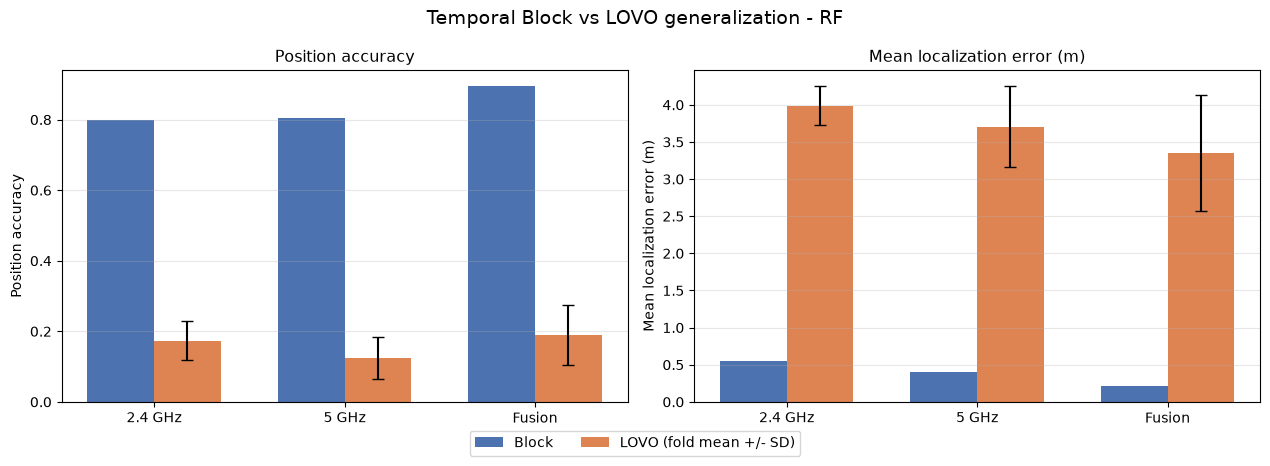

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/floor_plan_block_vs_lovo_fusion_rf.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


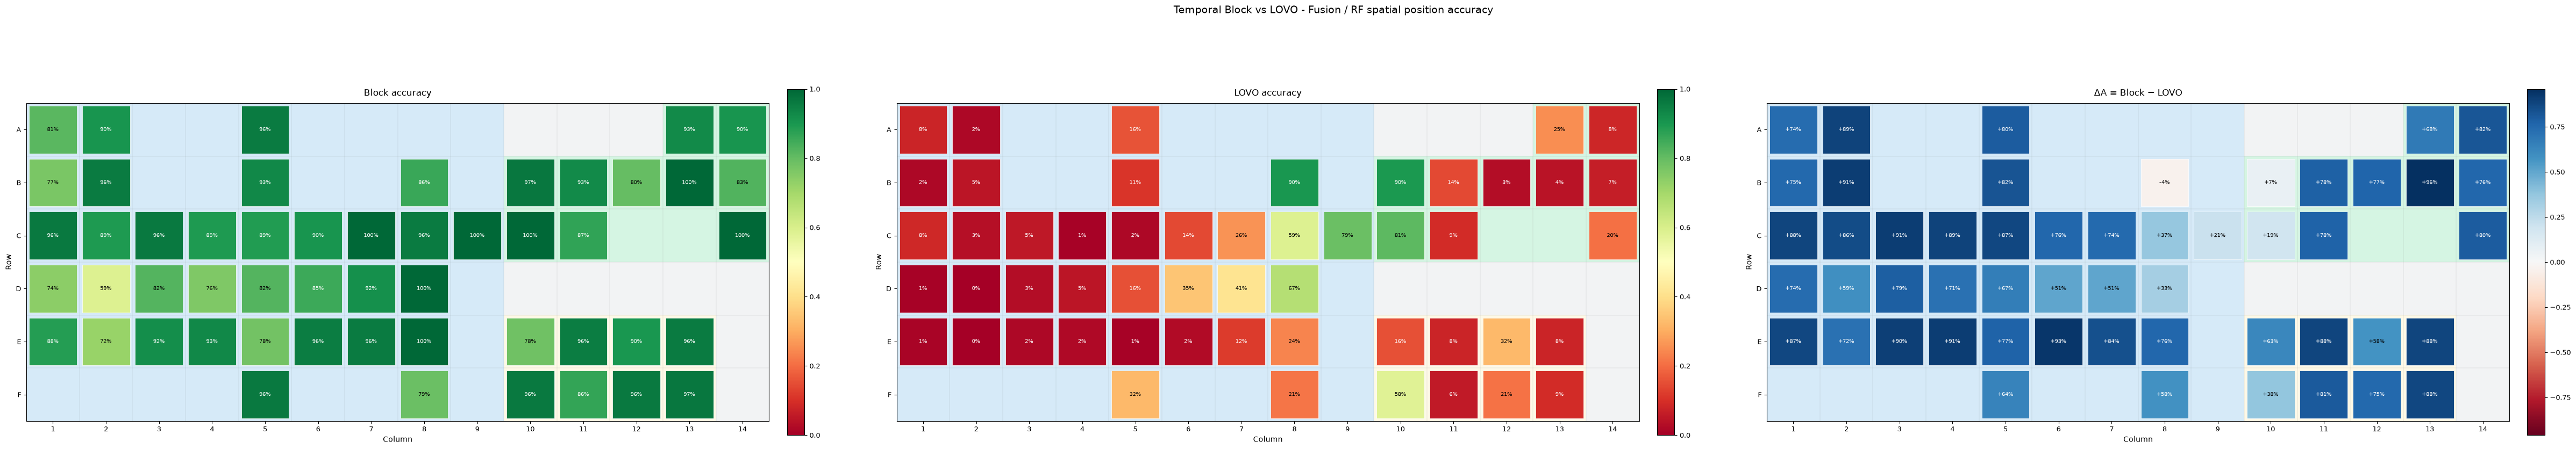

In [15]:
if has_block and has_lovo:
    plot_block_vs_lovo_metrics(
        master_table.loc[master_table["split"] == "block"],
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"block_vs_lovo_{_slugify('RF')}_metrics.png",
        show=DISPLAY_PLOTS,
    )

    block_predictions = all_global_predictions.loc[all_global_predictions["split_mode"] == "block"]
    lovo_predictions = all_global_predictions.loc[all_global_predictions["split_mode"] == "lovo"]
    block_fusion_rf_predictions = block_predictions.loc[
        (block_predictions["model"] == "RF") & (block_predictions["dataset"] == "Fusion")
    ]
    lovo_fusion_rf_predictions = lovo_predictions.loc[
        (lovo_predictions["model"] == "RF") & (lovo_predictions["dataset"] == "Fusion")
    ]
    plot_block_vs_lovo_floor_plan(
        block_fusion_rf_predictions,
        lovo_fusion_rf_predictions,
        title="Temporal Block vs LOVO - Fusion / RF spatial position accuracy",
        save_path=plots_dir / f"floor_plan_block_vs_lovo_{_slugify('Fusion')}_{_slugify('RF')}.png",
        show=DISPLAY_PLOTS,
    )
else:
    print("Temporal Block vs LOVO plots skipped: both splits are required.")